Set up dataset construction parameters

In [1]:
from utils.image_processing import sitk_load
import json
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

CONFIG = {
    "database_path": "../Chest-xray-landmark-dataset/Images",
    "output_path": "../Dataset/CXRAY/Landmarks_3_10",
    "scale_factor": 0.05, # 10% of the original average contour size
    "resolutions": ["full", "half", "quarter"], # Names are only for reference
    # 1, 1/2, 1/4 are the actual scale factors
    "organs": ["1", "2", "3", "4", "5"], # ID in the mask
    "organ_names": ["Left Lung", "Right Lung", "Heart", "Left Clavicle", "Right Clavicle"], # Name ID
    "inputsize": 512,
    # Set up data augmentation available
    "flip_h": False, # Allows for horizontal flipping
    "flip_v": False, # Allows for vertical flipping
    "rotate": True, # Allows for small rotations
    "transpose": False # Allows for transposing the image (swapping width and height)
}

os.makedirs(CONFIG["output_path"], exist_ok=True)
with open(os.path.join(CONFIG["output_path"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=4)

First, we organize the dataset in folders:

images/ ...

masks/ ...

This reorganization is not required if the masks are provided in a file, with a list of paths.

In [ ]:
def organize_dataset(config):
    """
    Organizes the dataset into images and masks folders and creates a file list.
    
    Args:
    config (dict): Configuration dictionary containing paths and other settings.
    
    Returns:
    tuple: (image_list_path, mask_list_path)
    """
    image_dir = Path(config['output_path']) / 'images'
    landmarks_dir = Path(config['output_path']) / 'landmarks'
    
    image_dir.mkdir(parents=True, exist_ok=True)
    landmarks_dir.mkdir(parents=True, exist_ok=True)
    
    image_list = []
    
    left_lungs = Path(config['database_path'].replace('Images', 'landmarks')) / 'LL'
    right_lungs = Path(config['database_path'].replace('Images', 'landmarks')) / 'RL'
    hearts = Path(config['database_path'].replace('Images', 'landmarks')) / 'H'
    left_clavicles = Path(config['database_path'].replace('Images', 'landmarks')) / 'LCLA'
    right_clavicles = Path(config['database_path'].replace('Images', 'landmarks')) / 'RCLA'
    
    # This part will need to be adapted for each specific dataset
    for patient in Path(config['database_path']).iterdir():
        if ".png" not in str(patient):
            continue
        
        image_path = patient
        image_id = image_path.stem
        
        image_array = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        new_image_path = image_dir / f"{image_id}.png"
        landmark_path = landmarks_dir / f"{image_id}.json"
        
        cv2.imwrite(str(new_image_path), image_array)
        
        # now for landmarks 
        landmarks = {}
        
        landmark_id = image_id + ".npy"
        
        if (left_lungs / landmark_id).exists():
            landmark = np.load(left_lungs / landmark_id)
            organ_mask = np.zeros_like(image_array)
            cv2.drawContours(organ_mask, [landmark.astype(np.int32)], -1, 1, thickness=cv2.FILLED)
            contours, _ = cv2.findContours(organ_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            largest_contour = max(contours, key=cv2.contourArea)
            landmarks["1"] = largest_contour.reshape(-1, 2).tolist()
        
        if (right_lungs / landmark_id).exists():
            landmark = np.load(right_lungs / landmark_id)
            organ_mask = np.zeros_like(image_array)
            cv2.drawContours(organ_mask, [landmark.astype(np.int32)], -1, 1, thickness=cv2.FILLED)
            contours, _ = cv2.findContours(organ_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            largest_contour = max(contours, key=cv2.contourArea)
            landmarks["2"] = largest_contour.reshape(-1, 2).tolist()
            
        if (hearts / landmark_id).exists():
            landmark = np.load(hearts / landmark_id)
            organ_mask = np.zeros_like(image_array)
            cv2.drawContours(organ_mask, [landmark.astype(np.int32)], -1, 1, thickness=cv2.FILLED)
            contours, _ = cv2.findContours(organ_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            largest_contour = max(contours, key=cv2.contourArea)
            landmarks["3"] = largest_contour.reshape(-1, 2).tolist()
        
        if (left_clavicles / landmark_id).exists():
            landmark = np.load(left_clavicles / landmark_id)
            organ_mask = np.zeros_like(image_array)
            cv2.drawContours(organ_mask, [landmark.astype(np.int32)], -1, 1, thickness=cv2.FILLED)
            contours, _ = cv2.findContours(organ_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            largest_contour = max(contours, key=cv2.contourArea)
            landmarks["4"] = largest_contour.reshape(-1, 2).tolist()
        
        if (right_clavicles / landmark_id).exists():
            landmark = np.load(right_clavicles / landmark_id)
            organ_mask = np.zeros_like(image_array)
            cv2.drawContours(organ_mask, [landmark.astype(np.int32)], -1, 1, thickness=cv2.FILLED)
            contours, _ = cv2.findContours(organ_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            largest_contour = max(contours, key=cv2.contourArea)
            landmarks["5"] = largest_contour.reshape(-1, 2).tolist()
            
        image_list.append(str(image_id + ".png"))
        
        with open(landmark_path, 'w') as f:
            json.dump(landmarks, f)
                
    # Write file lists
    image_list_path = Path(config['output_path']) / 'image_list.txt'
    
    with open(image_list_path, 'w') as f:
        f.write('\n'.join(image_list))
    
    return

In [ ]:
# Step 1: Organize dataset
organize_dataset(CONFIG)

Then the landmarks can be directly generated from the masks.

In [ ]:
from utils.image_processing import get_contour_lengths

# Step 3: Get contour lengths
contour_lengths = get_contour_lengths(CONFIG, os.path.join(CONFIG["output_path"], "landmarks"))

Contour lengths:
Organ 1: min=878, max=2222, avg=1570.26
Organ 2: min=960, max=2177, avg=1635.46
Organ 3: min=817, max=1417, avg=1072.04
Organ 4: min=348, max=659, avg=497.39
Organ 5: min=327, max=663, avg=499.91


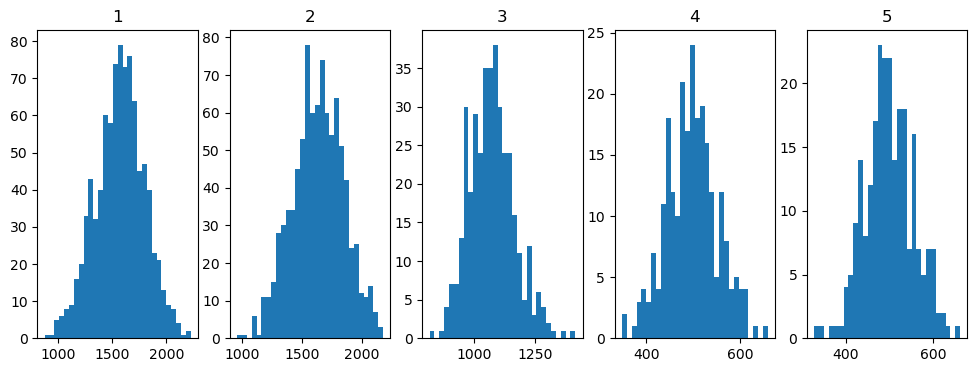

In [ ]:
print("Contour lengths:")
for organ, lengths in contour_lengths.items():
    print(f"Organ {organ}: min={min(lengths)}, max={max(lengths)}, avg={sum(lengths)/len(lengths):.2f}")

plt.figure(figsize=(12, 4))

for i, j in enumerate(contour_lengths.keys()):
    plt.subplot(1, 5, i+1)
    plt.hist(contour_lengths[j], bins=30)
    plt.title(j)

In [2]:
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


(np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(1.0))
(np.float64(0.5234360234360234), np.float64(1.0), np.float64(0.0), np.float64(1.0))
(np.float64(0.0), np.float64(1.0), np.float64(0.9531223422015865), np.float64(1.0))
(np.float64(0.4296860234360234), np.float64(0.0), np.float64(1.0), np.float64(1.0))
(np.float64(1.0), np.float64(0.0), np.float64(0.09375), np.float64(1.0))


/tmp/ipykernel_230666/178726271.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


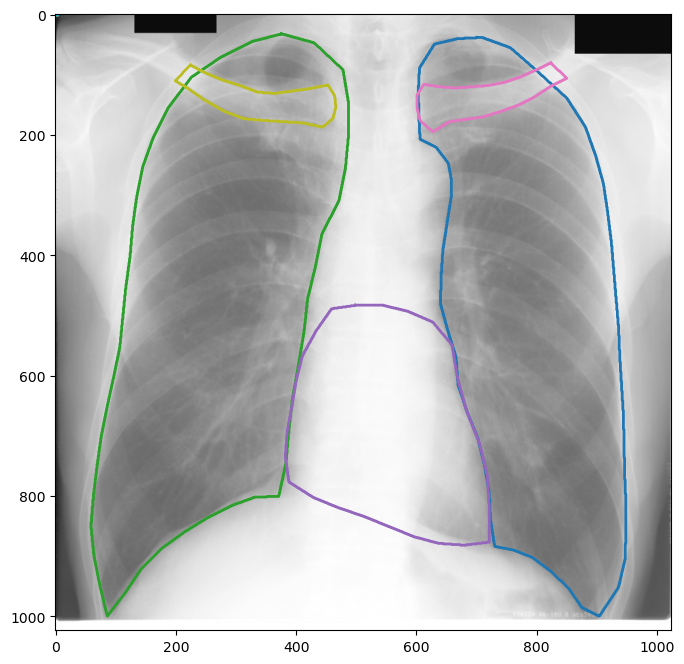

In [3]:
image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path(CONFIG['output_path']) / 'images' / image_list[253]
landmarks_path = Path(CONFIG['output_path']) / 'landmarks' / Path(image_list[253]).with_suffix('.json')

image = cv2.imread(str(image_path))
landmarks = json.load(open(landmarks_path))

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)
    print(color)

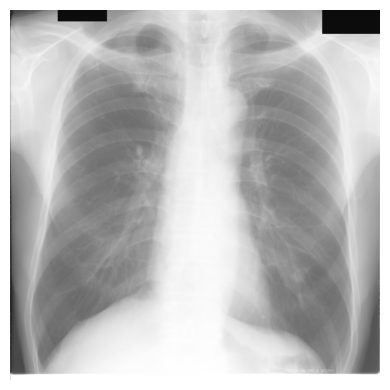

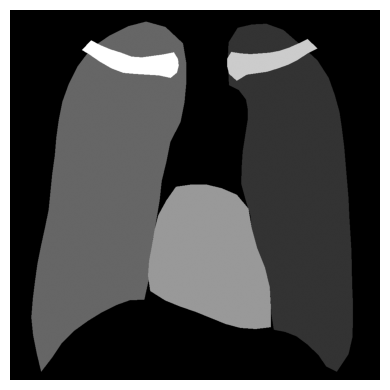

In [5]:
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
# remove white border
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.tight_layout()

mask = np.zeros(image.shape[:2], dtype=np.uint8)
for organ, contour in landmarks.items():
    contour = np.array(contour, dtype=np.int32)
    cv2.drawContours(mask, [contour], -1, int(organ), thickness=cv2.FILLED)

plt.figure(figsize=(4, 4))
plt.imshow(mask, cmap='gray')
plt.axis('off')
# remove white border
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.tight_layout()
plt.show()

The following code generates the required adjacency matrixes to run the code, from the dictionary of contour lengths.

In [ ]:
# force reload the package, with one line
import importlib
import utils.matrix_ops
importlib.reload(utils.matrix_ops)

from utils.matrix_ops import generate_adjacency_matrices, save_matrices, create_sampling_matrix, generate_edge_info

adjacency_matrices, downsampling_matrices, upsampling_matrices = generate_adjacency_matrices(contour_lengths, CONFIG)

os.makedirs(f"{CONFIG['output_path']}/Naive", exist_ok=True)

for res in CONFIG["resolutions"]:
    save_matrices(adjacency_matrices[res], res, CONFIG)

for name, matrices in downsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/Naive/downsampling_{name}.npy", block_matrix)

for name, matrices in upsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/Naive/upsampling_{name}.npy", block_matrix)

generate_edge_info(CONFIG)

Organ 1 - Contour len mean: 1570.2634467618002 - Atlas contour size: 80
Adjacency matrices sizes: [('full', 80), ('half', 40), ('quarter', 20)]
Downsampling matrices sizes: [('to_half', 40), ('to_quarter', 20)]
Organ 2 - Contour len mean: 1635.457738748628 - Atlas contour size: 80
Adjacency matrices sizes: [('full', 80), ('half', 40), ('quarter', 20)]
Downsampling matrices sizes: [('to_half', 40), ('to_quarter', 20)]
Organ 3 - Contour len mean: 1072.0391644908616 - Atlas contour size: 64
Adjacency matrices sizes: [('full', 64), ('half', 32), ('quarter', 16)]
Downsampling matrices sizes: [('to_half', 32), ('to_quarter', 16)]
Organ 4 - Contour len mean: 497.390243902439 - Atlas contour size: 64
Adjacency matrices sizes: [('full', 64), ('half', 32), ('quarter', 16)]
Downsampling matrices sizes: [('to_half', 32), ('to_quarter', 16)]
Organ 5 - Contour len mean: 499.9146341463415 - Atlas contour size: 64
Adjacency matrices sizes: [('full', 64), ('half', 32), ('quarter', 16)]
Downsampling mat

: 

In [ ]:
# Load the files .txt and separate them in training validation and test. Use a 80 - 10 - 10 split
import numpy as np
import random

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'

with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()
    
# samples should be taking without putting the same patient in different sets
# the list contains files in the format patient/type/image.png
# so first separate the files by patient

datasets = {}
for image in image_list:
    if image.startswith('MCU'):
        if datasets.get('MCU') is None:
            datasets['MCU'] = [image]
        else:
            datasets['MCU'].append(image)
    elif image.startswith('JPC'):
        if datasets.get('JPC') is None:
            datasets['JPC'] = [image]
        else:
            datasets['JPC'].append(image)
    elif image.startswith('CHN'):
        if datasets.get('CHN') is None:
            datasets['CHN'] = [image]
        else:
            datasets['CHN'].append(image)
    else:
        if datasets.get('Other') is None:
            datasets['Other'] = [image]
        else:
            datasets['Other'].append(image)

# now we have a dictionary with images and the dataset they belong to
# we need to split them evenly 
train_images = []
val_images = []
test_images = []

for key in datasets.keys():
    random.shuffle(datasets[key])
    n_samples = len(datasets[key])
    
    train_size = int(0.8 * n_samples)
    val_size = int(0.1 * n_samples)
    
    train_images_ = datasets[key][:train_size]
    val_images_ = datasets[key][train_size:train_size + val_size]
    test_images_ = datasets[key][train_size + val_size:]
    
    train_images.extend(train_images_)
    val_images.extend(val_images_)
    test_images.extend(test_images_)

# save as txt

train_image_list_path = Path(CONFIG['output_path']) / 'train.txt'
val_image_list_path = Path(CONFIG['output_path']) / 'val.txt'
test_image_list_path = Path(CONFIG['output_path']) / 'test.txt'

with open(train_image_list_path, 'w') as f:
    f.write('\n'.join(train_images))
with open(val_image_list_path, 'w') as f:
    f.write('\n'.join(val_images))
with open(test_image_list_path, 'w') as f:
    f.write('\n'.join(test_images))